# Interactive Retail Profit Analysis Tool
### Using Superstore data to evaluate discount strategy and business performance

## 1. Problem Definition

Retail businesses often use discount strategies to increase sales, but excessive discounting can significantly reduce profitability.

This project aims to help retail managers understand the relationship between discount and profit, and answer the key question:

**"How should we adjust discount strategies to maximise profit?"**

The intended users of this tool are retail managers and business analysts who need to make data-driven pricing and promotion decisions.

To support this objective, the analysis focuses on how discount levels influence profitability across different product categories, regions, and time periods.

## 2. Dataset and Business Context

The dataset used in this project is the Superstore retail dataset, which contains 10,194 transaction records and 21 variables, including order date, region, category, sales, discount, and profit. The dataset is suitable for business analysis because it captures key operational dimensions of a retail business, including pricing, product performance, and geographic performance.

This dataset was selected because it allows analysis of the relationship between sales growth and profitability, which is highly relevant for retail decision-making.

**Data Source**: Sample Superstore dataset (from Kaggle).  
**Date Accessed**: April 2026.

In [7]:
import pandas as pd

df = pd.read_csv("samplesuperstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

## 3. Data Cleaning

In [7]:
df = df.dropna()

df['Order Date'] = pd.to_datetime(df['Order Date'])

#Missing values were removed to ensure data consistency. The `Order Date` column was converted into datetime format to enable time-series analysis.

## 4. Exploratory Business Overview

### 4.1 Sales by Category

In [8]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

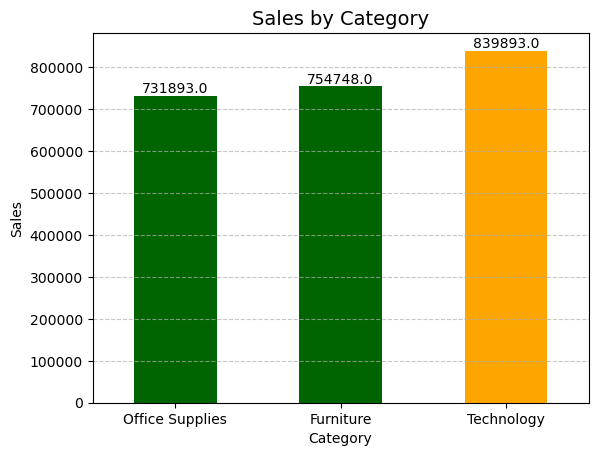

In [9]:
import matplotlib.pyplot as plt

# Find the maximum value
max_value = category_sales.max()
category_sales = category_sales.sort_values()

# Automatically generate a list of colors
colors = ['orange' if v == max_value else 'darkgreen' for v in category_sales]

# draw
ax = category_sales.plot(kind='bar', color=colors)

# Add numerical labels
for i, v in enumerate(category_sales):
    ax.text(i, v, str(round(v, 0)), ha='center', va='bottom')

plt.title("Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

The category analysis shows that **Technology** generates the highest total sales, ahead of Furniture and Office Supplies. This suggests that Technology is the main revenue driver of the business. 

### Insight
Technology appears to be the strongest category in terms of revenue generation. This may reflect higher-value items and more stable demand. For management, this means Technology should remain a priority in inventory planning, promotional budgeting, and customer targeting.

### 4.2 Sales by Region

In [10]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    503170.6728
East       691828.1680
South      391721.9050
West       739813.6085
Name: Sales, dtype: float64

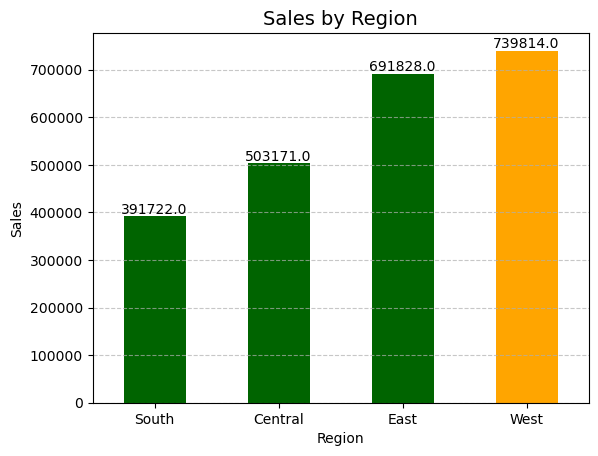

In [11]:
import matplotlib.pyplot as plt

%matplotlib inline

# Calculate the maximum value
max_value = region_sales.max()
region_sales = region_sales.sort_values()

# Automatically generate a list of colors
colors = ['orange' if v == max_value else 'darkgreen' for v in region_sales]

# draw
ax = region_sales.plot(kind='bar', color=colors)

# Add numerical labels
for i, v in enumerate(region_sales):
    ax.text(i, v, str(round(v, 0)), ha='center', va='bottom')

# beautify
plt.title("Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Regional analysis shows that the **West** region has the highest total sales, followed by the East, Central, and South. :contentReference[oaicite:10]{index=10}

### Insight
The West region is the strongest market in sales terms, indicating better market penetration or stronger customer demand. This suggests that the company may benefit from reinforcing successful practices in the West and investigating why lower-performing regions, especially the South, lag behind.

### 4.3 Time Trend

In [12]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

In [13]:
monthly_sales = monthly_sales.sort_index()

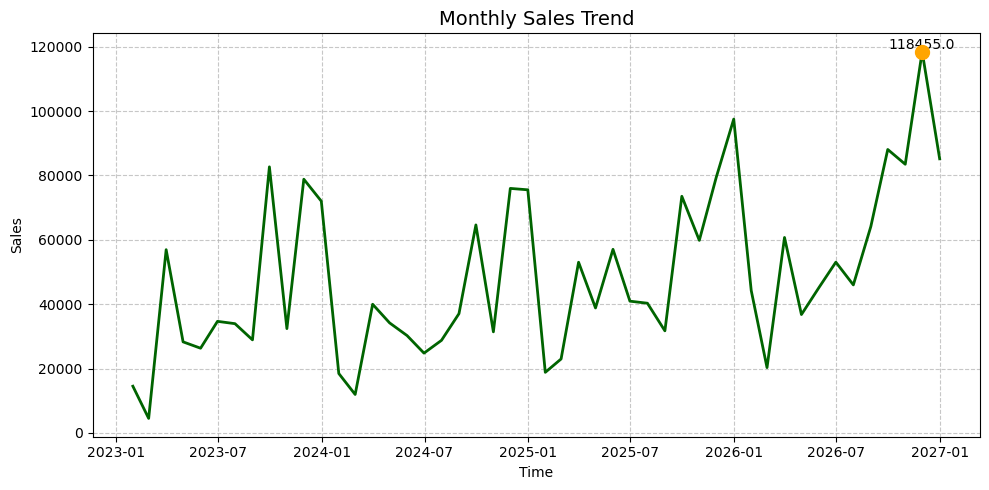

In [14]:
import matplotlib.pyplot as plt

%matplotlib inline

# Make the graph wider and make it more like a report.
plt.figure(figsize=(10, 5))  

# draw
plt.plot(monthly_sales, color='darkgreen', linewidth=2)

# Calculate the maximum value
max_value = monthly_sales.max()
max_date = monthly_sales.idxmax()

plt.scatter(max_date, max_value, color='orange', s=100, zorder=5)

# Add labels
plt.text(max_date, max_value, 
         f"{round(max_value,0)}", 
         ha='center', va='bottom')

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Sales")

# Add grid
plt.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Monthly sales show an overall upward trend over time, although short-term fluctuations are visible. Peak periods may reflect seasonality, promotions, or temporary surges in demand. 

### Insight
The business shows evidence of growth, but sales volatility suggests that performance is not equally stable across all periods. Managers could use this information to identify peak seasons and allocate inventory, staffing, and promotional resources more efficiently.

## 6. Core Analysis: Discount and Profitability ⭐⭐⭐

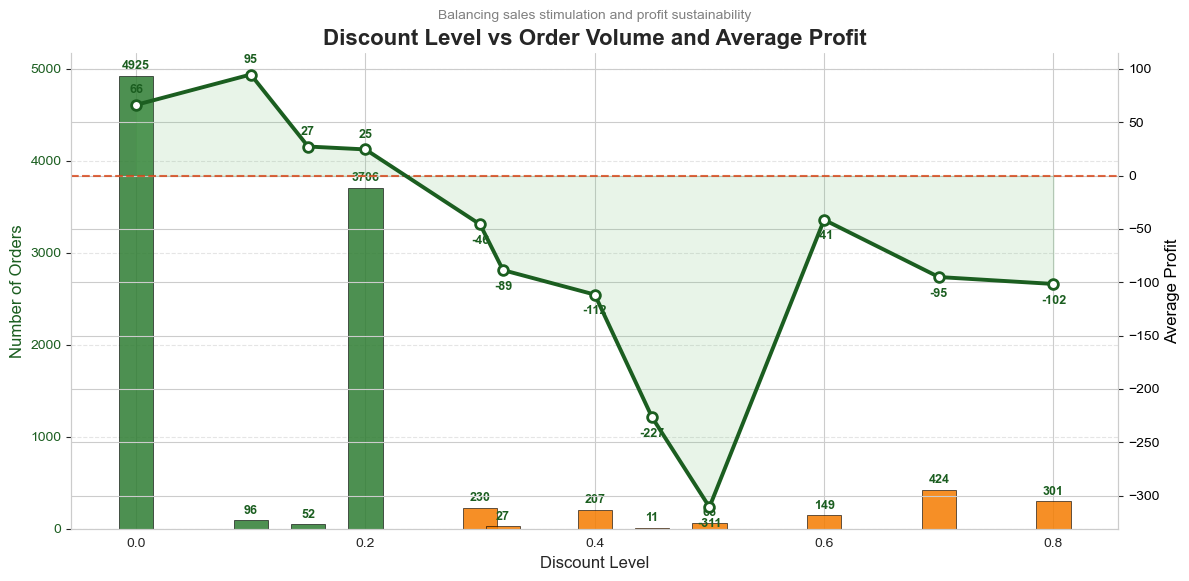

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data preparation
# Calculate order volume by discount level
order_count = df.groupby('Discount').size().reset_index(name='Order Count')

# Calculate average profit by discount level
avg_profit = df.groupby('Discount')['Profit'].mean().reset_index(name='Average Profit')

# Merge the two results
discount_summary = order_count.merge(avg_profit, on='Discount')


# 2. Create figure and twin axes
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))


# 3. Bar chart: Order volume
# Color logic:
# low-to-moderate discount = green
# high discount = orange
bar_colors = ['#2E7D32' if x <= 0.2 else '#F57C00' for x in discount_summary['Discount']]

bars = ax1.bar(
    discount_summary['Discount'],
    discount_summary['Order Count'],
    color=bar_colors,
    alpha=0.85,
    width=0.03,
    edgecolor='black',
    linewidth=0.5,
    zorder=2
)

ax1.set_xlabel('Discount Level', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12, color='#1B5E20')
ax1.tick_params(axis='y', labelcolor='#1B5E20')

# Add bar labels
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 35,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#1B5E20',
        fontweight='bold'
    )

# 4. Line chart: Average profit
ax2 = ax1.twinx()

# Trend shadow area
ax2.fill_between(
    discount_summary['Discount'],
    discount_summary['Average Profit'],
    color='#66BB6A',
    alpha=0.15,
    zorder=1
)

# Main line
ax2.plot(
    discount_summary['Discount'],
    discount_summary['Average Profit'],
    color='#1B5E20',
    linewidth=2.8,
    marker='o',
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2,
    markeredgecolor='#1B5E20',
    zorder=5
)

# Zero-profit reference line
ax2.axhline(
    0,
    color='#D84315',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel('Average Profit', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add line labels
for x, y in zip(discount_summary['Discount'], discount_summary['Average Profit']):
    ax2.text(
        x,
        y + (8 if y >= 0 else -10),
        f'{y:.0f}',
        ha='center',
        va='bottom' if y >= 0 else 'top',
        fontsize=9,
        color='#1B5E20',
        fontweight='bold'
    )


# 5. Beautify chart
plt.title(
    'Discount Level vs Order Volume and Average Profit',
    fontsize=16,
    fontweight='bold'
)

plt.suptitle(
    'Balancing sales stimulation and profit sustainability',
    fontsize=10,
    color='gray',
    y=0.96
)

ax1.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(left=False, bottom=False, right=False)

plt.tight_layout()
plt.show()

### Insight：

This chart highlights a clear trade-off between sales volume and profitability across different discount levels.

At low discount levels, average profit remains positive, indicating that modest discounts can support demand without seriously damaging margins. In particular, discount levels around 0.0–0.2 are associated with both relatively high order volume and positive average profit, suggesting a more sustainable pricing range.

However, as discount levels become deeper, average profit declines sharply and turns negative. This indicates that although discounting may still generate some transactions, the financial return from those sales becomes increasingly weak. The most severe deterioration appears around the mid-to-high discount range, where average profit falls substantially below zero.

From a business perspective, the figure suggests that excessive discounting is not an efficient long-term strategy. While discounts may stimulate order activity in selected cases, aggressive price reductions appear to erode profitability more quickly than they improve sales outcomes. Therefore, firms should apply discounts selectively and aim to identify an optimal discount range that balances customer demand with profit sustainability.
""")

### 7. Top Products and Revenue Concentration

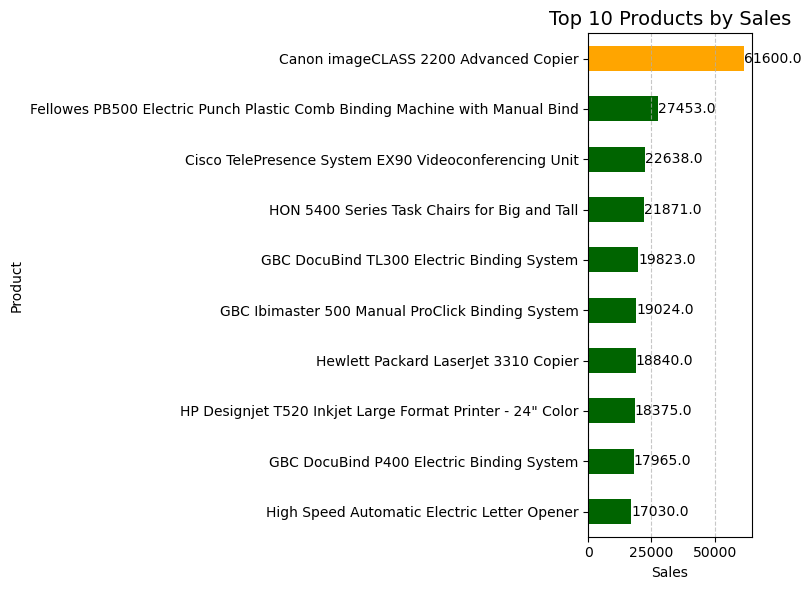

In [18]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(8, 6))

# Re-generate the data
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Sort
top_products = top_products.sort_values()

# Find the maximum value
max_value = top_products.max()

# Color scheme
colors = ['orange' if v == max_value else 'darkgreen' for v in top_products]

# Draw
ax = top_products.plot(kind='barh', color=colors)

# Add label
for i, v in enumerate(top_products):
    ax.text(v, i, str(round(v, 0)), va='center')

plt.title("Top 10 Products by Sales", fontsize=14)
plt.xlabel("Sales")
plt.ylabel("Product")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The top 10 products contribute a disproportionately large share of total sales, indicating that revenue is concentrated among a relatively small number of items. 

### Insight
This pattern suggests a concentration effect similar to the Pareto principle. The company depends heavily on a limited number of high-performing products, which creates both opportunity and risk. These products should be prioritised, but the business should also reduce over-reliance by improving the performance of weaker items.


## 8. Final Recommendation

Based on the analysis, three recommendations can be made:

1. **Control excessive discounting**  
   Discounts should be applied more selectively, because higher discount levels are associated with weaker profitability.

2. **Prioritise high-performing categories and regions**  
   Technology and the West region are key performance drivers and should remain strategic priorities.

3. **Adopt a more targeted pricing strategy**  
   Discount policies should vary by category and product type rather than being applied uniformly across the business.

## 9. Limitations

This project is based on historical transactional data and does not include product cost structure, competitor pricing, customer behaviour, or inventory constraints. Therefore, the analysis can identify patterns but cannot fully explain the causes behind them.

In addition, the analysis mainly uses descriptive methods, so the findings should be interpreted as decision support rather than causal proof.